In [34]:
import pandas as pd

in this notebook we finalize the data for model training, we will combine fractions, filter and split

# Load files

In [31]:
quant_path = r"C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\nsaf_diann.parquet"
fraction_groups_path = r"C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\parition_combiner\fraction_groups.tsv"
metadata_path = r"C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\run_metadata_combined.tsv"

In [18]:
quant_df = pd.read_parquet(quant_path)
fraction_groups_df = pd.read_csv(fraction_groups_path, sep="\t")
metadata_df = pd.read_csv(metadata_path, sep="\t")

C:\Users\sander\AppData\Local\Temp\ipykernel_32840\2817487212.py:3: DtypeWarning: Columns (0: collision_energy, 1: collision_energy_evidence) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(metadata_path, sep="\t")


# 1. Deduplicate DDA/DIA overlap

Some runs appear in both DDA (dNSAF) and DIA (DIA-NN) quantification. We keep only the row matching the correct acquisition mode. Runs labeled "DDA; DIA" (unresolvable) are dropped.

In [19]:
ACQUISITION_TO_SOURCE = {"DDA": "dda_dnsaf", "DIA": "diann"}

# Tag quant rows with acquisition from metadata
quant_with_acq = quant_df.merge(
    metadata_df[["pxd", "run", "acquisition"]].drop_duplicates(subset=["pxd", "run"]),
    on=["pxd", "run"], how="left"
)

# Find duplicate (pxd, run) rows
quant_with_acq["is_dupe"] = quant_with_acq.duplicated(subset=["pxd", "run"], keep=False)

# Non-duplicates: keep as-is
non_dupes = quant_with_acq[~quant_with_acq["is_dupe"]].copy()

# Duplicates: keep only where source matches acquisition mode
dupes = quant_with_acq[quant_with_acq["is_dupe"]].copy()
dupes["expected_source"] = dupes["acquisition"].map(ACQUISITION_TO_SOURCE)
resolved = dupes[dupes["source"] == dupes["expected_source"]].copy()

# Combine and clean up
quant_deduped = pd.concat([non_dupes, resolved], ignore_index=True)
quant_deduped = quant_deduped.drop(columns=["is_dupe", "acquisition", "expected_source"])
quant_deduped = quant_deduped.drop_duplicates(subset=["pxd", "run"], keep="first")
quant_deduped = quant_deduped.sort_values(["pxd", "run"]).reset_index(drop=True)

n_dupes = quant_with_acq["is_dupe"].sum()
n_dropped = len(quant_df) - len(quant_deduped)
print(f"Before: {len(quant_df):,} rows ({n_dupes:,} duplicates)")
print(f"  Resolved (kept correct source): {len(resolved):,}")
print(f"  Dropped (unresolvable DDA;DIA): {n_dupes - len(resolved):,}")
print(f"After: {len(quant_deduped):,} rows")
print(f"Remaining duplicates: {quant_deduped.duplicated(subset=['pxd', 'run']).sum()}")

Before: 89,626 rows (7,435 duplicates)
  Resolved (kept correct source): 1,118
  Dropped (unresolvable DDA;DIA): 6,317
After: 83,309 rows
Remaining duplicates: 0


# combine the fractions

In [20]:
# Sum fractions into samples using fraction_groups
protein_cols = [c for c in quant_deduped.columns if c not in ["pxd", "run", "source"]]

# Tag runs with their sample_base
frac_lookup = fraction_groups_df[["pxd", "run", "sample_base"]].drop_duplicates()
quant_tagged = quant_deduped.merge(frac_lookup, on=["pxd", "run"], how="left")

is_fraction = quant_tagged["sample_base"].notna()
fractions = quant_tagged[is_fraction]
singletons = quant_tagged[~is_fraction]

# Sum protein columns across fractions per sample
fractions_summed = fractions.groupby(["pxd", "sample_base"])[protein_cols].sum().reset_index()
fractions_summed = fractions_summed.rename(columns={"sample_base": "run"})

# Combine: singletons + summed fractions
quant_final = pd.concat([
    singletons[["pxd", "run"] + protein_cols],
    fractions_summed[["pxd", "run"] + protein_cols],
], ignore_index=True).sort_values(["pxd", "run"]).reset_index(drop=True)

print(f"Before: {len(quant_deduped):,} rows")
print(f"  Singletons: {len(singletons):,}")
print(f"  Fraction runs: {len(fractions):,} -> {len(fractions_summed):,} samples")
print(f"After: {len(quant_final):,} rows")

Before: 83,309 rows
  Singletons: 74,787
  Fraction runs: 8,522 -> 823 samples
After: 75,610 rows


# Filtering

### A. species

only want human samples

In [21]:
# see the distribution of species
# Join metadata to quant_final to see species distribution                                                                                        
species = quant_final[["pxd", "run"]].merge(                                                                                                      
    metadata_df[["pxd", "run", "organism"]].drop_duplicates(subset=["pxd", "run"]),                                                               
    on=["pxd", "run"], how="left")                                                                                                                                                 
                                                                                                                                                
print(f"Runs with organism: {species['organism'].notna().sum():,} / {len(species):,}")
print(f"\nSpecies distribution:")
print(species["organism"].value_counts().head(20).to_string())
print(f"\nNo organism: {species['organism'].isna().sum():,}")

Runs with organism: 67,393 / 75,610

Species distribution:
organism
Homo sapiens                                                                                                  57158
Mus musculus                                                                                                   4394
Arabidopsis thaliana                                                                                           2150
Escherichia coli                                                                                                968
Saccharomyces cerevisiae                                                                                        672
Homo sapiens; Mus musculus                                                                                      531
Homo sapiens; Mus musculus; Saccharomyces cerevisiae                                                            364
Escherichia coli; Homo sapiens                                                                                  216
Homo

In [22]:
# only keep human runs
# Keep only runs where organism contains "Homo sapiens"                                                                                           
species = quant_final[["pxd", "run"]].merge(                                                                                                      
    metadata_df[["pxd", "run", "organism"]].drop_duplicates(subset=["pxd", "run"]),                                                               
    on=["pxd", "run"], how="left"                                                                                                                   )                                                                                                                                                 
                                                                                                                                                
is_human = species["organism"].str.contains("Homo sapiens", case=False, na=False)
quant_human = quant_final[is_human.values].reset_index(drop=True)

print(f"Before: {len(quant_final):,} runs")
print(f"Human: {len(quant_human):,} ({len(quant_human)/len(quant_final):.1%})")
print(f"Dropped: {len(quant_final) - len(quant_human):,}")
print(f"PXDs: {quant_human['pxd'].nunique():,}")

Before: 75,610 runs
Human: 59,015 (78.1%)
Dropped: 16,595
PXDs: 1,245


### B. Expressed proteins

In [23]:
# Filter runs with fewer than 500 detected proteins                                                                                               
proteins_per_run = (quant_final[protein_cols] > 0).sum(axis=1)                                                                                    
before = len(quant_final)                                                                                                                           
quant_filtered = quant_final[proteins_per_run >= 500].reset_index(drop=True)                                                                      
after = len(quant_filtered)                                                                                                                                                                                                                                                                           
print(f"Before: {before:,} runs")
print(f"After: {after:,} runs (>= 500 proteins)")
print(f"Dropped: {before - after:,} runs ({(before - after) / before:.1%})")
print(f"\nProteins per run (after filter):")
proteins_kept = (quant_filtered[protein_cols] > 0).sum(axis=1)
print(f"  Min: {proteins_kept.min()}")
print(f"  Median: {int(proteins_kept.median())}")
print(f"  Max: {proteins_kept.max()}")

Before: 75,610 runs
After: 53,134 runs (>= 500 proteins)
Dropped: 22,476 runs (29.7%)

Proteins per run (after filter):
  Min: 500
  Median: 2269
  Max: 15166


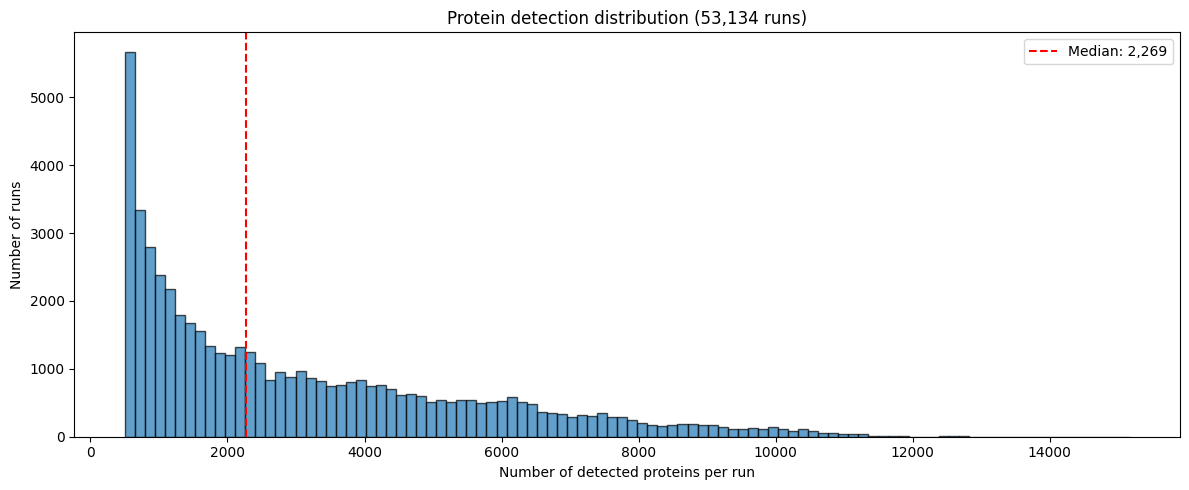

In [24]:
# histogram of non-zero proteins per run
import matplotlib.pyplot as plt                                                                                                                   
                                                                                                                                                
proteins_per_run = (quant_filtered[protein_cols] > 0).sum(axis=1)                                                                                 
fig, ax = plt.subplots(figsize=(12, 5))                                                                                                           
ax.hist(proteins_per_run, bins=100, edgecolor="black", alpha=0.7)                                                                                 
ax.set_xlabel("Number of detected proteins per run")
ax.set_ylabel("Number of runs")
ax.set_title(f"Protein detection distribution ({len(quant_filtered):,} runs)")
ax.axvline(proteins_per_run.median(), color="red", linestyle="--", label=f"Median: {int(proteins_per_run.median()):,}")
ax.legend()
plt.tight_layout()
plt.show()

# 2. tissue

In [25]:
# Tissue distribution for human runs                                                                                                              
tissue = quant_human[["pxd", "run"]].merge(                                                                                                       
    metadata_df[["pxd", "run", "tissue"]].drop_duplicates(subset=["pxd", "run"]),                                                                 
    on=["pxd", "run"], how="left"                                                                                                                   )                                                                                                                                                 
                                                                                                                                                
print(f"Runs with tissue: {tissue['tissue'].notna().sum():,} / {len(tissue):,} ({tissue['tissue'].notna().mean():.1%})")
print(f"Unique tissues: {tissue['tissue'].nunique()}")
print(f"\nTissue distribution:")
print(tissue["tissue"].value_counts().head(90).to_string())
print(f"\nNo tissue: {tissue['tissue'].isna().sum():,}")

Runs with tissue: 35,528 / 59,015 (60.2%)
Unique tissues: 155

Tissue distribution:
tissue
thyroid gland                                                                        5525
blood plasma                                                                         5279
brain                                                                                3282
breast                                                                               1496
epithelial cell                                                                      1379
fibroblast                                                                           1199
lung                                                                                 1196
cerebrospinal fluid                                                                   907
blood                                                                                 829
blood serum                                                                           683
prostate 

# split the data

we need to split the data in train/test/valid. to prevent dataleackage we split by pxd

In [26]:
from sklearn.model_selection import GroupShuffleSplit

# Split configuration — easy to adjust                                                                                                            
SPLIT = {
    "train": 0.9,                                                                                                                                 
    "val": 0.05,                                                                                                                                  
    "test": 0.05,
}
assert abs(sum(SPLIT.values()) - 1.0) < 1e-9, "Split ratios must sum to 1.0"

# Split by PXD (all runs from the same project stay together)
pxds = quant_filtered["pxd"].values

# First split: train vs rest
rest_size = SPLIT["val"] + SPLIT["test"]
gss1 = GroupShuffleSplit(n_splits=1, test_size=rest_size, random_state=42)
train_idx, temp_idx = next(gss1.split(quant_filtered, groups=pxds))

# Second split: val vs test (proportion relative to rest)
test_of_rest = SPLIT["test"] / rest_size
temp_pxds = pxds[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=test_of_rest, random_state=42)
val_idx_rel, test_idx_rel = next(gss2.split(temp_idx, groups=temp_pxds))
val_idx = temp_idx[val_idx_rel]
test_idx = temp_idx[test_idx_rel]

train_df = quant_filtered.iloc[train_idx].reset_index(drop=True)
val_df = quant_filtered.iloc[val_idx].reset_index(drop=True)
test_df = quant_filtered.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_df):,} runs ({train_df['pxd'].nunique():,} PXDs) — {len(train_df)/len(quant_filtered):.1%}")
print(f"Val:   {len(val_df):,} runs ({val_df['pxd'].nunique():,} PXDs) — {len(val_df)/len(quant_filtered):.1%}")
print(f"Test:  {len(test_df):,} runs ({test_df['pxd'].nunique():,} PXDs) — {len(test_df)/len(quant_filtered):.1%}")

# Verify no PXD overlap
assert len(set(train_df["pxd"]) & set(val_df["pxd"])) == 0, "PXD leak: train/val"
assert len(set(train_df["pxd"]) & set(test_df["pxd"])) == 0, "PXD leak: train/test"
assert len(set(val_df["pxd"]) & set(test_df["pxd"])) == 0, "PXD leak: val/test"
print("\nNo PXD overlap between splits")

Train: 49,108 runs (1,185 PXDs) — 92.4%
Val:   1,731 runs (66 PXDs) — 3.3%
Test:  2,295 runs (66 PXDs) — 4.3%

No PXD overlap between splits


In [27]:
# Check which tissues appear in each split                                                                                                        
meta_cols = metadata_df[["pxd", "run", "tissue"]].drop_duplicates(subset=["pxd", "run"])
split_tissues = {}                                                                                                                                
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:                                                                  
    merged = split_df[["pxd", "run"]].merge(meta_cols, on=["pxd", "run"], how="left")
    # Expand multi-value tissues (e.g., "brain; heart" -> ["brain", "heart"])
    tissues = set()
    for t in merged["tissue"].dropna():
        for part in str(t).split(";"):
            tissues.add(part.strip())
    split_tissues[name] = tissues

all_tissues = sorted(split_tissues["train"] | split_tissues["val"] | split_tissues["test"])

print(f"{'tissue':35s} {'train':>6s} {'val':>6s} {'test':>6s}")
print("-" * 60)
for t in all_tissues:
    in_train = "Y" if t in split_tissues["train"] else "-"
    in_val = "Y" if t in split_tissues["val"] else "-"
    in_test = "Y" if t in split_tissues["test"] else "-"
    missing = " !" if in_train == "-" or in_val == "-" or in_test == "-" else ""
    print(f"{t:35s} {in_train:>6s} {in_val:>6s} {in_test:>6s}{missing}")

# Summary
in_all = split_tissues["train"] & split_tissues["val"] & split_tissues["test"]
not_in_all = (split_tissues["train"] | split_tissues["val"] | split_tissues["test"]) - in_all
print(f"\nTissues in all splits: {len(in_all)}")
print(f"Tissues missing from at least one split: {len(not_in_all)}")
if not_in_all:
    print(f"  {sorted(not_in_all)}")

tissue                               train    val   test
------------------------------------------------------------
B cells                                  Y      -      - !
CD4+ T cells                             Y      -      - !
CD8+ T cells                             Y      -      - !
NK cells                                 Y      -      - !
PBMCs                                    Y      -      Y !
T cells                                  Y      -      Y !
adipose tissue                           Y      Y      Y
adrenal gland                            Y      -      - !
anus                                     Y      -      - !
blood                                    Y      Y      Y
blood plasma                             Y      Y      Y
blood serum                              Y      Y      - !
bone                                     Y      -      - !
bone marrow                              Y      Y      Y
brain                                    Y      Y      Y
breast 

# save the data

In [28]:
import os                                                                                                                                         

output_dir = r"C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann"                                                      
os.makedirs(output_dir, exist_ok=True)                                                                                                            
                                                                                                                                                
# Save quant splits
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    path = os.path.join(output_dir, f"quant_{name}.parquet")
    split_df.to_parquet(path, index=False)
    print(f"Saved {path} ({len(split_df):,} runs)")

# Save single metadata file with a 'split' column
meta_cols = metadata_df.drop_duplicates(subset=["pxd", "run"])

all_splits = []
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split_meta = split_df[["pxd", "run"]].merge(meta_cols, on=["pxd", "run"], how="left")
    split_meta["split"] = name
    all_splits.append(split_meta)

metadata_out = pd.concat(all_splits, ignore_index=True)
path = os.path.join(output_dir, "metadata.tsv")
metadata_out.to_csv(path, sep="\t", index=False)
print(f"Saved {path} ({len(metadata_out):,} runs, split column: {metadata_out['split'].value_counts().to_dict()})")

print(f"\nAll files saved to {output_dir}")

Saved C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann\quant_train.parquet (49,108 runs)
Saved C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann\quant_val.parquet (1,731 runs)
Saved C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann\quant_test.parquet (2,295 runs)
Saved C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann\metadata.tsv (53,134 runs, split column: {'train': 49108, 'test': 2295, 'val': 1731})

All files saved to C:\Users\sander\OneDrive\Bureaublad\Projects\prot_GPT\code\agentic-metadata\data\model_ready\nsaf_diann
